# Spaceship Titanic — Modelling

This notebook trains and compares two classifiers — **Logistic Regression** and
**XGBoost** — for predicting whether a passenger was transported. It uses the
clean dataset produced by `02_preprocessing.ipynb`.

**Design note — no data leakage:** preprocessing (one-hot encoding + scaling) and
the estimator live in a single scikit-learn `Pipeline`. The pipeline is fit only
on the training split, and inside `GridSearchCV` it is refit on each
cross-validation fold. The validation set never influences the fitted
transformers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Load the processed data

The target `Transported` is a boolean; we convert it to integers (0/1) for the
models.

In [2]:
train = pd.read_csv("../data/processed_train.csv")

X = train.drop(columns=["Transported"])
y = train["Transported"].astype(int)

X.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,Side,OnboardSpending
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,B,P,0.0
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,F,S,736.0
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,A,S,10383.0
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,A,S,5176.0
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,F,S,1091.0


## 2. Train / validation split

We split **before** fitting any transformer. Every model below is trained on
`X_train` and evaluated on the held-out `X_val`.

In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, train_size=0.8, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, "| Validation:", X_val.shape)

Train: (6954, 13) | Validation: (1739, 13)


## 3. Reusable building blocks

Rather than repeating the same preprocessing code for every experiment, we define
small helpers:

- `make_preprocessor` builds a `ColumnTransformer` (one-hot for categoricals,
  standard-scaling for numerics) for a given set of feature columns.
- `make_pipeline` chains the preprocessor with an estimator.
- The feature groups are defined once so the feature-engineering experiments only
  need to change a list.

In [4]:
# Feature groups for the three experiment variants.
BASE_CATEGORICAL = ["HomePlanet", "CryoSleep", "Destination", "VIP", "Deck", "Side"]
BASE_NUMERIC = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

# "OnboardSpending" variant: base numerics plus the engineered total-spend feature.
SPENDING_NUMERIC = BASE_NUMERIC + ["OnboardSpending"]

# "Feature selection" variant: drop Destination, VIP, Deck and Age.
SELECTED_CATEGORICAL = ["HomePlanet", "CryoSleep", "Side"]
SELECTED_NUMERIC = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]


def make_preprocessor(categorical, numeric):
    """One-hot encode categoricals, standard-scale numerics, drop the rest."""
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical),
            ("num", StandardScaler(), numeric),
        ],
        remainder="drop",
    )


def make_pipeline(estimator, categorical=BASE_CATEGORICAL, numeric=BASE_NUMERIC):
    """Chain the preprocessor with an estimator into a single leak-free pipeline."""
    return Pipeline([
        ("preprocessor", make_preprocessor(categorical, numeric)),
        ("model", estimator),
    ])

In [5]:
# Collect every experiment's validation accuracy here for the final comparison.
results = {}


def evaluate(name, pipeline):
    """Fit on the training split, score on the validation split, and record it."""
    pipeline.fit(X_train, y_train)
    acc = accuracy_score(y_val, pipeline.predict(X_val))
    results[name] = acc
    print(f"{name}: {acc:.4f}")
    return pipeline

## 4. Logistic Regression

### 4.1 Baseline

A logistic regression with default hyperparameters on the base feature set.

In [6]:
logreg_basic = make_pipeline(
    LogisticRegression(max_iter=5000, solver="saga", random_state=RANDOM_STATE)
)
evaluate("Logistic Regression (Basic)", logreg_basic);

Logistic Regression (Basic): 0.7947


### 4.2 Hyperparameter tuning with Grid Search

We tune the regularisation strength `C` and the L1/L2 mix (`l1_ratio`, where
`0.0` is pure L2 and `1.0` is pure L1) with 5-fold cross-validation, using the
`saga` solver. Hyperparameters are prefixed with `model__` because the estimator
sits inside the pipeline.

In [7]:
logreg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__l1_ratio": [0.0, 1.0],  # 0.0 = pure L2, 1.0 = pure L1
}

logreg_grid = GridSearchCV(
    make_pipeline(LogisticRegression(max_iter=5000, solver="saga", random_state=RANDOM_STATE)),
    logreg_param_grid, cv=5, scoring="accuracy", n_jobs=-1,
)
logreg_grid.fit(X_train, y_train)

print("Best parameters:", logreg_grid.best_params_)
print("Best CV accuracy:", round(logreg_grid.best_score_, 4))

best_logreg = logreg_grid.best_estimator_
val_pred = best_logreg.predict(X_val)
results["Logistic Regression (Grid Search)"] = accuracy_score(y_val, val_pred)
print("Validation accuracy:", round(results["Logistic Regression (Grid Search)"], 4))

Best parameters: {'model__C': 10, 'model__l1_ratio': 1.0}
Best CV accuracy: 0.7909
Validation accuracy: 0.7947


### 4.3 Confusion matrix

How the tuned model splits its correct and incorrect predictions on the
validation set.

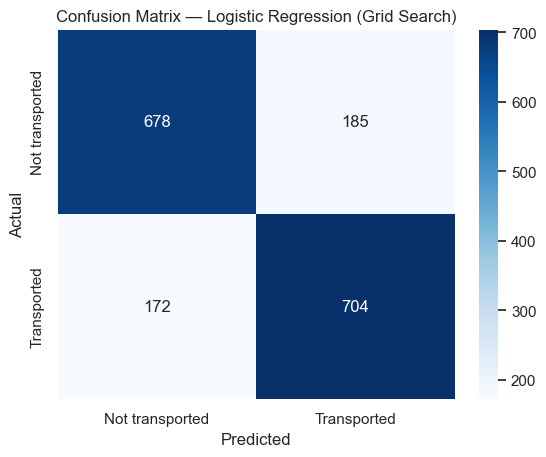

In [8]:
cm = confusion_matrix(y_val, val_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not transported", "Transported"],
            yticklabels=["Not transported", "Transported"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression (Grid Search)")
plt.show()

### 4.4 Feature interpretability (odds ratios)

Logistic regression coefficients can be read as **odds ratios** via `exp(coef)`:

- **OR > 1** — the feature increases the odds of being transported.
- **OR < 1** — the feature decreases them.

In [9]:
feature_names = best_logreg.named_steps["preprocessor"].get_feature_names_out()
coefs = best_logreg.named_steps["model"].coef_[0]

summary = pd.DataFrame({"Coefficient": coefs}, index=feature_names)
summary["Odds Ratio"] = np.exp(summary["Coefficient"])
summary = summary.sort_values("Coefficient", ascending=False)
summary

,Coefficient,Odds Ratio
cat__Deck_C,2.022172,7.554718
cat__HomePlanet_Europa,1.455061,4.284746
cat__CryoSleep_True,1.370381,3.936852
cat__Deck_B,1.250981,3.493770
num__FoodCourt,0.793992,2.212211
cat__Deck_D,0.697473,2.008670
cat__Deck_F,0.629270,1.876241
cat__Side_S,0.519567,1.681300
cat__HomePlanet_Mars,0.482704,1.620451
num__ShoppingMall,0.263402,1.301350


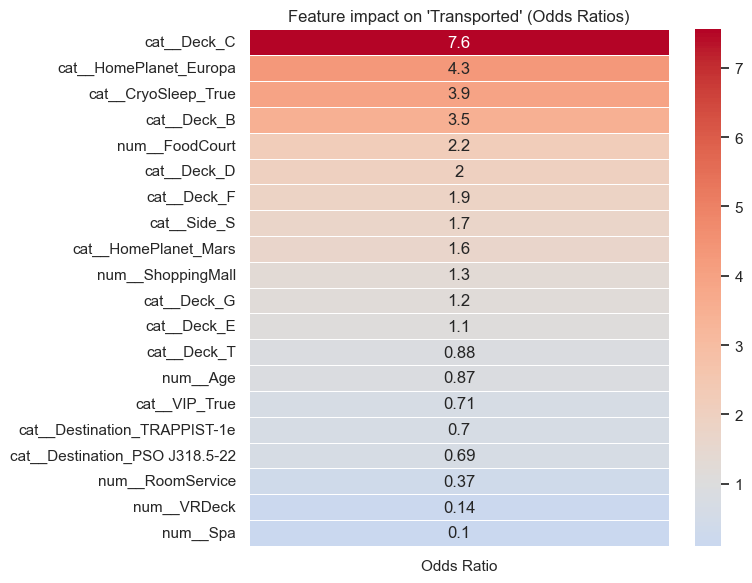

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(summary[["Odds Ratio"]], annot=True, cmap="coolwarm",
            center=1, linewidths=0.5)
plt.title("Feature impact on 'Transported' (Odds Ratios)")
plt.tight_layout()
plt.show()

### 4.5 Feature engineering: `OnboardSpending`

Re-run the grid search with the engineered total-spend feature added.

In [11]:
logreg_spending = GridSearchCV(
    make_pipeline(LogisticRegression(max_iter=5000, solver="saga", random_state=RANDOM_STATE),
                  numeric=SPENDING_NUMERIC),
    logreg_param_grid, cv=5, scoring="accuracy", n_jobs=-1,
)
logreg_spending.fit(X_train, y_train)

acc = accuracy_score(y_val, logreg_spending.predict(X_val))
results["Logistic Regression (OnboardSpending)"] = acc
print("Validation accuracy:", round(acc, 4))

Validation accuracy: 0.7947


### 4.6 Feature selection

Drop the features with odds ratios closest to 1 (`Destination`, `VIP`, `Deck`,
`Age`) and re-tune.

In [12]:
logreg_selected = GridSearchCV(
    make_pipeline(LogisticRegression(max_iter=5000, solver="saga", random_state=RANDOM_STATE),
                  categorical=SELECTED_CATEGORICAL, numeric=SELECTED_NUMERIC),
    logreg_param_grid, cv=5, scoring="accuracy", n_jobs=-1,
)
logreg_selected.fit(X_train, y_train)

acc = accuracy_score(y_val, logreg_selected.predict(X_val))
results["Logistic Regression (Feature Selection)"] = acc
print("Validation accuracy:", round(acc, 4))

Validation accuracy: 0.7878


## 5. XGBoost

The same four experiments with a gradient-boosted tree model.

> **Fixes vs. the original:** the deprecated `silent=1` and `use_label_encoder`
> arguments are removed (they raise errors in current XGBoost), and each block now
> prints its **own** accuracy variable — the original printed the logistic
> regression result by mistake.

In [13]:
def make_xgb():
    return XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE,
                         n_jobs=-1)

### 5.1 Baseline

In [14]:
xgb_basic = make_pipeline(make_xgb())
evaluate("XGBoost (Basic)", xgb_basic);

XGBoost (Basic): 0.8016


### 5.2 Hyperparameter tuning with Grid Search

In [15]:
xgb_param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__max_depth": [3, 5, 7],
    "model__subsample": [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    make_pipeline(make_xgb()), xgb_param_grid, cv=5, scoring="accuracy", n_jobs=-1,
)
xgb_grid.fit(X_train, y_train)

print("Best parameters:", xgb_grid.best_params_)
print("Best CV accuracy:", round(xgb_grid.best_score_, 4))

acc = accuracy_score(y_val, xgb_grid.best_estimator_.predict(X_val))
results["XGBoost (Grid Search)"] = acc
print("Validation accuracy:", round(acc, 4))

Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 1.0}
Best CV accuracy: 0.8031
Validation accuracy: 0.8085


### 5.3 With `OnboardSpending`

In [16]:
xgb_spending = GridSearchCV(
    make_pipeline(make_xgb(), numeric=SPENDING_NUMERIC),
    xgb_param_grid, cv=5, scoring="accuracy", n_jobs=-1,
)
xgb_spending.fit(X_train, y_train)

acc = accuracy_score(y_val, xgb_spending.predict(X_val))
results["XGBoost (OnboardSpending)"] = acc
print("Validation accuracy:", round(acc, 4))

Validation accuracy: 0.816


### 5.4 With feature selection

In [17]:
xgb_selected = GridSearchCV(
    make_pipeline(make_xgb(), categorical=SELECTED_CATEGORICAL,
                  numeric=SELECTED_NUMERIC),
    xgb_param_grid, cv=5, scoring="accuracy", n_jobs=-1,
)
xgb_selected.fit(X_train, y_train)

acc = accuracy_score(y_val, xgb_selected.predict(X_val))
results["XGBoost (Feature Selection)"] = acc
print("Validation accuracy:", round(acc, 4))

Validation accuracy: 0.8033


## 6. Results overview

All validation accuracies side by side.

In [18]:
results_df = (
    pd.DataFrame({"Model": results.keys(),
                  "Validation Accuracy": results.values()})
    .sort_values("Validation Accuracy", ascending=False)
    .reset_index(drop=True)
)
results_df

,Model,Validation Accuracy
0,XGBoost (OnboardSpending),0.815986
1,XGBoost (Grid Search),0.808511
2,XGBoost (Feature Selection),0.803335
3,XGBoost (Basic),0.801610
4,Logistic Regression (Grid Search),0.794710
5,Logistic Regression (OnboardSpending),0.794710
6,Logistic Regression (Basic),0.794710
7,Logistic Regression (Feature Selection),0.787809


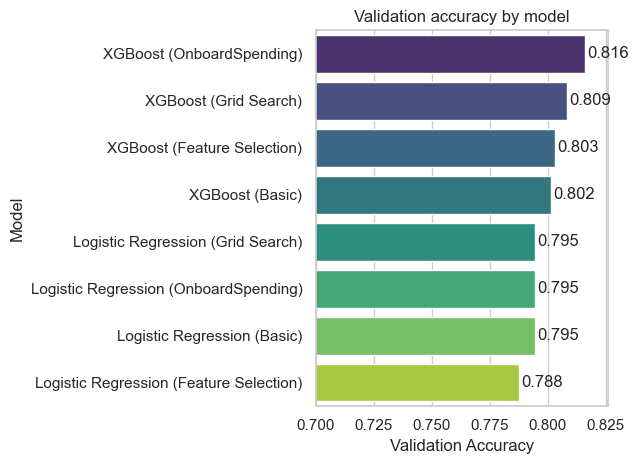

In [19]:
ax = sns.barplot(data=results_df, y="Model", x="Validation Accuracy",
                 palette="viridis", hue="Model", legend=False)
ax.set_xlim(0.7, results_df["Validation Accuracy"].max() + 0.01)
ax.set_title("Validation accuracy by model")
for i, v in enumerate(results_df["Validation Accuracy"]):
    ax.text(v + 0.001, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()

## 7. Conclusion

- **XGBoost** consistently edges out logistic regression, which is expected for a
  dataset with non-linear interactions between cryo-sleep, spending and cabin
  features.
- **Grid Search** yields only modest gains over the baselines — the features, not
  the hyperparameters, are the main driver of performance here.
- The engineered **`OnboardSpending`** feature gives at most a marginal
  improvement; the individual spending columns already carry that signal.
- **Feature selection** slightly *reduces* accuracy, suggesting the dropped
  features still contribute a little predictive value.

The strongest configuration is reported at the top of the results table above.
Validation accuracy sits in the high-70s, which is a reasonable result for these
two model families on this dataset.